Best x = -0.31841174756637425
Minimum = -9.896353593555535


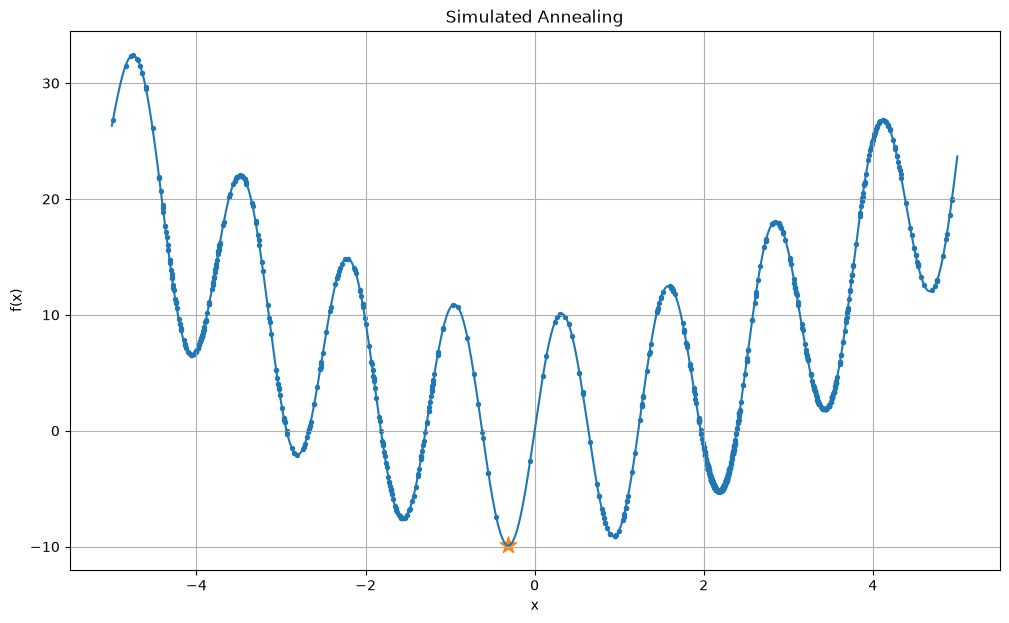

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math



def f(x):
    return x**2 + 10 * np.sin(5 * x)


current_x = 4.0

best_x = current_x
best_value = f(current_x)

temperature = 200.0
cooling_rate = 0.995

path = [current_x]

while temperature > 0.01:

    # Generate neighboring solution
    new_x = current_x + random.uniform(-0.5, 0.5)

    # Keep x inside search space
    if new_x < -5 or new_x > 5:
        continue

    current_value = f(current_x)
    new_value = f(new_x)

    # Difference
    delta = new_value - current_value

    # Accept better solution
    if delta < 0:

        current_x = new_x

    # Sometimes accept worse solution
    else:

        probability = math.exp(-delta / temperature)

        if random.random() < probability:
            current_x = new_x

    # Update best solution
    if f(current_x) < best_value:

        best_x = current_x
        best_value = f(current_x)

    path.append(current_x)

    # Cool down
    temperature *= cooling_rate


print("Best x =", best_x)
print("Minimum =", best_value)



x_values = np.linspace(-5, 5, 1000)
y_values = f(x_values)

plt.figure(figsize=(12, 7))

plt.plot(x_values, y_values)

# Plot the path taken by SA
path_values = [f(x) for x in path]

plt.scatter(
    path,
    path_values,
    s=8
)

# Best solution
plt.scatter(
    best_x,
    best_value,
    s=150,
    marker="*"
)

plt.xlabel("x")
plt.ylabel("f(x)")

plt.title("Simulated Annealing")

plt.grid(True)

plt.show()

In [ ]:
import json
import random
import math
import os
import folium
import matplotlib.pyplot as plt
from build_graph import GRAPH_PATH, build_tsp_graph

from places import PLACES


if not os.path.exists(GRAPH_PATH):
    build_tsp_graph()

with open(GRAPH_PATH, "r") as f:
    graph = json.load(f)


cities = list(graph.keys())


def route_distance(route):
    total = 0.0

    for i in range(len(route) - 1):
        total += graph[route[i]][route[i + 1]]["km"]

    return total


def create_initial_route(start):
    remaining = [city for city in cities if city != start]
    random.shuffle(remaining)

    return [start] + remaining + [start]


def create_neighbor(route):
    new_route = route.copy()

    i, j = random.sample(
        range(1, len(route) - 1),
        2
    )

    new_route[i], new_route[j] = (
        new_route[j],
        new_route[i]
    )

    return new_route


def simulated_annealing(
    start,
    initial_temperature=100,
    cooling_rate=0.995,
    minimum_temperature=0.001,
    iterations_per_temperature=100
):

    current_route = create_initial_route(start)
    current_distance = route_distance(current_route)

    best_route = current_route.copy()
    best_distance = current_distance

    temperature = initial_temperature
    history = []

    while temperature > minimum_temperature:

        for _ in range(iterations_per_temperature):

            new_route = create_neighbor(current_route)
            new_distance = route_distance(new_route)

            delta = new_distance - current_distance

            if delta < 0:
                current_route = new_route
                current_distance = new_distance

            else:
                probability = math.exp(
                    -delta / temperature
                )

                if random.random() < probability:
                    current_route = new_route
                    current_distance = new_distance

            if current_distance < best_distance:
                best_route = current_route.copy()
                best_distance = current_distance

            history.append(best_distance)

        temperature *= cooling_rate

    return best_route, best_distance, history

[1/66] Kupondole <-> Maitighar
    1.12 km (1.3 min)
[2/66] Kupondole <-> Babarmahal
    2.53 km (3.5 min)
[3/66] Kupondole <-> Tinkune
    4.3 km (5.8 min)
[4/66] Kupondole <-> Balkumari
    4.8 km (5.4 min)
[5/66] Kupondole <-> Gwarko
    4.0 km (4.9 min)
[6/66] Kupondole <-> Koteshwor
    6.6 km (7.2 min)
[7/66] Kupondole <-> Baneshwor
    2.66 km (3.7 min)
[8/66] Kupondole <-> Satdobato
    4.11 km (4.7 min)
[9/66] Kupondole <-> Kumaripati
    2.75 km (2.6 min)
[10/66] Kupondole <-> Pulchowk
    1.07 km (1.1 min)
[11/66] Kupondole <-> Jawalakhel
    2.01 km (2.0 min)
[12/66] Maitighar <-> Babarmahal
    2.64 km (3.6 min)
[13/66] Maitighar <-> Tinkune
    4.41 km (6.0 min)
[14/66] Maitighar <-> Balkumari
    3.83 km (5.9 min)
[15/66] Maitighar <-> Gwarko
    4.85 km (5.6 min)
[16/66] Maitighar <-> Koteshwor
    7.45 km (7.9 min)
[17/66] Maitighar <-> Baneshwor
    2.78 km (3.8 min)
[18/66] Maitighar <-> Satdobato
    4.96 km (5.4 min)
[19/66] Maitighar <-> Kumaripati
    3.59 km (3.

In [ ]:
def draw_tsp_map(route, distance):

    start = route[0]

    m = folium.Map(
        location=PLACES[start],
        zoom_start=13
    )

    # Mark locations
    for i, city in enumerate(route[:-1], start=1):

        lat, lon = PLACES[city]

        folium.CircleMarker(
            location=(lat, lon),
            radius=7,
            color="blue",
            fill=True,
            popup=f"{i}. {city}",
            tooltip=city
        ).add_to(m)

    # Draw TSP route
    folium.PolyLine(
        [PLACES[city] for city in route],
        color="red",
        weight=5,
        tooltip=f"TSP distance: {distance:.2f} km"
    ).add_to(m)

    # Mark start
    folium.Marker(
        PLACES[start],
        popup=f"START: {start}",
        tooltip="Start",
        icon=folium.Icon(color="green")
    ).add_to(m)

    # Route numbers
    for i, city in enumerate(route[:-1], start=1):

        lat, lon = PLACES[city]

        folium.Marker(
            location=(lat, lon),
            icon=folium.DivIcon(
                html=f"""
                <div style="
                    font-size: 14px;
                    font-weight: bold;
                    color: black;
                    background-color: white;
                    border: 2px solid black;
                    border-radius: 50%;
                    width: 24px;
                    height: 24px;
                    text-align: center;
                    line-height: 24px;
                ">
                    {i}
                </div>
                """
            )
        ).add_to(m)

    import os

    os.makedirs("OUTPUT", exist_ok=True)
    m.save("OUTPUT/tsp_map.html")


In [9]:



def main():

    start = "Kupondole"

    print("\nStarting SA...")

    best_route, best_distance, history = simulated_annealing(
        start=start,
        initial_temperature=100,
        cooling_rate=0.995,
        minimum_temperature=0.001,
        iterations_per_temperature=100
    )

    print("SA finished.")

    print("\nBest route:")
    print(" → ".join(best_route))

    print(f"Total distance: {best_distance:.2f} km")

    print("\nDrawing map...")

    draw_tsp_map(best_route, best_distance)

    print("Map finished.")


if __name__ == "__main__":
    main()


Starting SA...
SA finished.

Best route:
Kupondole → Maitighar → Babarmahal → Tinkune → Balkumari → Chyasal → Gwarko → Satdobato → Kumaripati → Jawalakhel → Ekantakuna → Pulchowk → Kupondole
Total distance: 20.77 km

Drawing map...


KeyError: 'Chyasal'